In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('../../../data/bonbanh/cleaned/extra_cleaned_bonbanh.csv')

In [3]:
numerical_features = df.select_dtypes(include='number').columns

categorical_features = df.select_dtypes(
    include=['object', 'string', 'category']
).columns

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
Index(['price', 'year', 'volume', 'seats', 'doors', 'odo', 'province', 'lat',
       'lon'],
      dtype='str')

Categorical features:
Index(['url', 'brand', 'model', 'date', 'status', 'origin', 'style',
       'transmission', 'engine', 'exterior_color', 'interior_color', 'drive',
       'name'],
      dtype='str')


## EDA ##

### Distribution

CHỈ SỐ ĐỘ LỆCH (SKEWNESS):
- price (Giá xe gốc): 8.49
- year (Năm SX):      -1.31
- odo (Số KM):        4.88


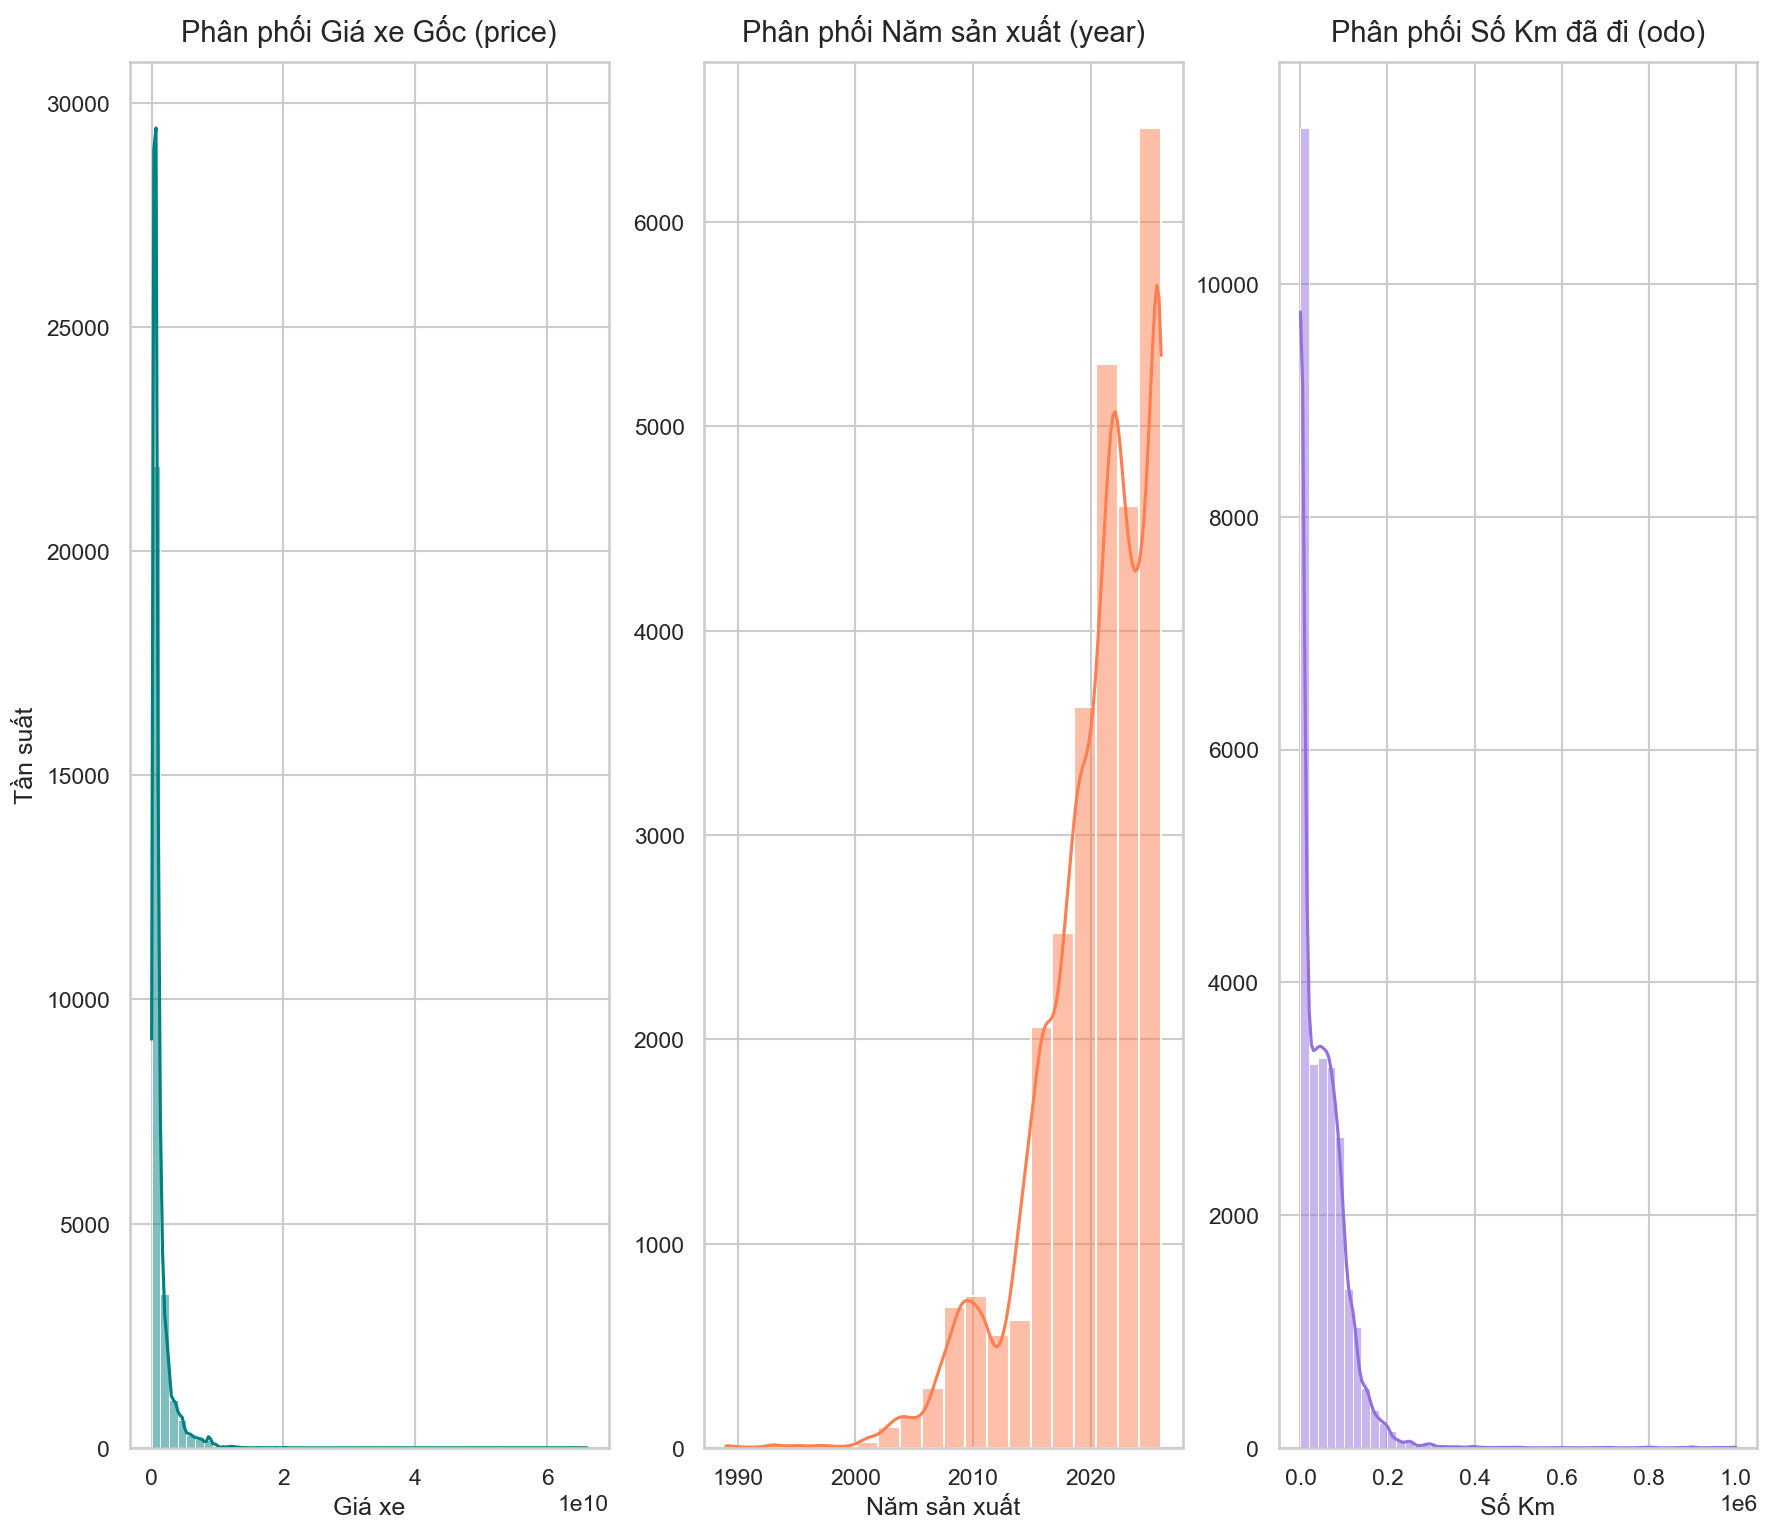

In [21]:
fig, axes = plt.subplots(
    1, 3,
    figsize=(14, 12),
    dpi=150
)
sns.set_theme(style="whitegrid")
axes = axes.flatten()

# 1. Biểu đồ phân phối cho Giá xe gốc (price)
sns.histplot(df['price'], kde=True, bins=50, ax=axes[0], color='teal')
axes[0].set_title('Phân phối Giá xe Gốc (price)', fontsize=14, pad=10)
axes[0].set_xlabel('Giá xe')
axes[0].set_ylabel('Tần suất')

# 2. Biểu đồ phân phối cho Năm sản xuất (year)
sns.histplot(df['year'], kde=True, bins=20, ax=axes[1], color='coral')
axes[1].set_title('Phân phối Năm sản xuất (year)', fontsize=14, pad=10)
axes[1].set_xlabel('Năm sản xuất')
axes[1].set_ylabel('')

# 3. Biểu đồ phân phối cho Số Km gốc (odo)
sns.histplot(df['odo'], kde=True, bins=50, ax=axes[2], color='mediumpurple')
axes[2].set_title('Phân phối Số Km đã đi (odo)', fontsize=14, pad=10)
axes[2].set_xlabel('Số Km')
axes[2].set_ylabel('')

# In ra các chỉ số thống kê về độ lệch
print("CHỈ SỐ ĐỘ LỆCH (SKEWNESS):")
print(f"- price (Giá xe gốc): {df['price'].skew():.2f}")
print(f"- year (Năm SX):      {df['year'].skew():.2f}")
print(f"- odo (Số KM):        {df['odo'].skew():.2f}")

plt.savefig(
    'Distribution.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()

In [5]:
df['odo'].describe([0.95,0.99,0.995])

count      27837.000000
mean       47778.453102
std        61371.175298
min            0.000000
95%       140000.000000
99%       220000.000000
99.5%     299460.000000
max      1000000.000000
Name: odo, dtype: float64

### Price:
- Phân phối lệch phải mạnh (highly right-skewed).
- Đa số xe tập trung ở vùng giá thấp và trung bình.
- Sử dụng Price_log thay thế làm target
### Year:
- Phần lớn xe nằm trong giai đoạn 2016–2024.
- Đỉnh khoảng 2021–2023.
- Phân phối này phản ánh đúng thị trường xe cũ hiện nay:
    + Xe quá cũ ít được rao bán.
    + Xe đời mới chiếm đa số.
### Odo:
- Lệch phải mạnh.
- Phần lớn xe dưới 100.000 km.
- Một số xe vượt 300.000–500.000 km, có thể do lỗi nhập liệu.
- Dùng winsorize để clip outlier.

In [4]:
# Logarit hóa price
def handle_price_outliers(df, column='price', apply_log=True):
    """
    Hàm này dùng để xử lý các outliers của biến price (VD: các xe trị giá cao như 66 tỷ...)
    Phát hiện bằng IQR và biến đổi Logarit.
    """
    df_out = df.copy()

    Q1 = df_out[column].quantile(0.25)
    Q3 = df_out[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    #Giữ lại outliers và biến đổi logarit
    if apply_log:
        df_out[f'{column}_log'] = np.log1p(df_out[column])
    return df_out
df = handle_price_outliers(df)

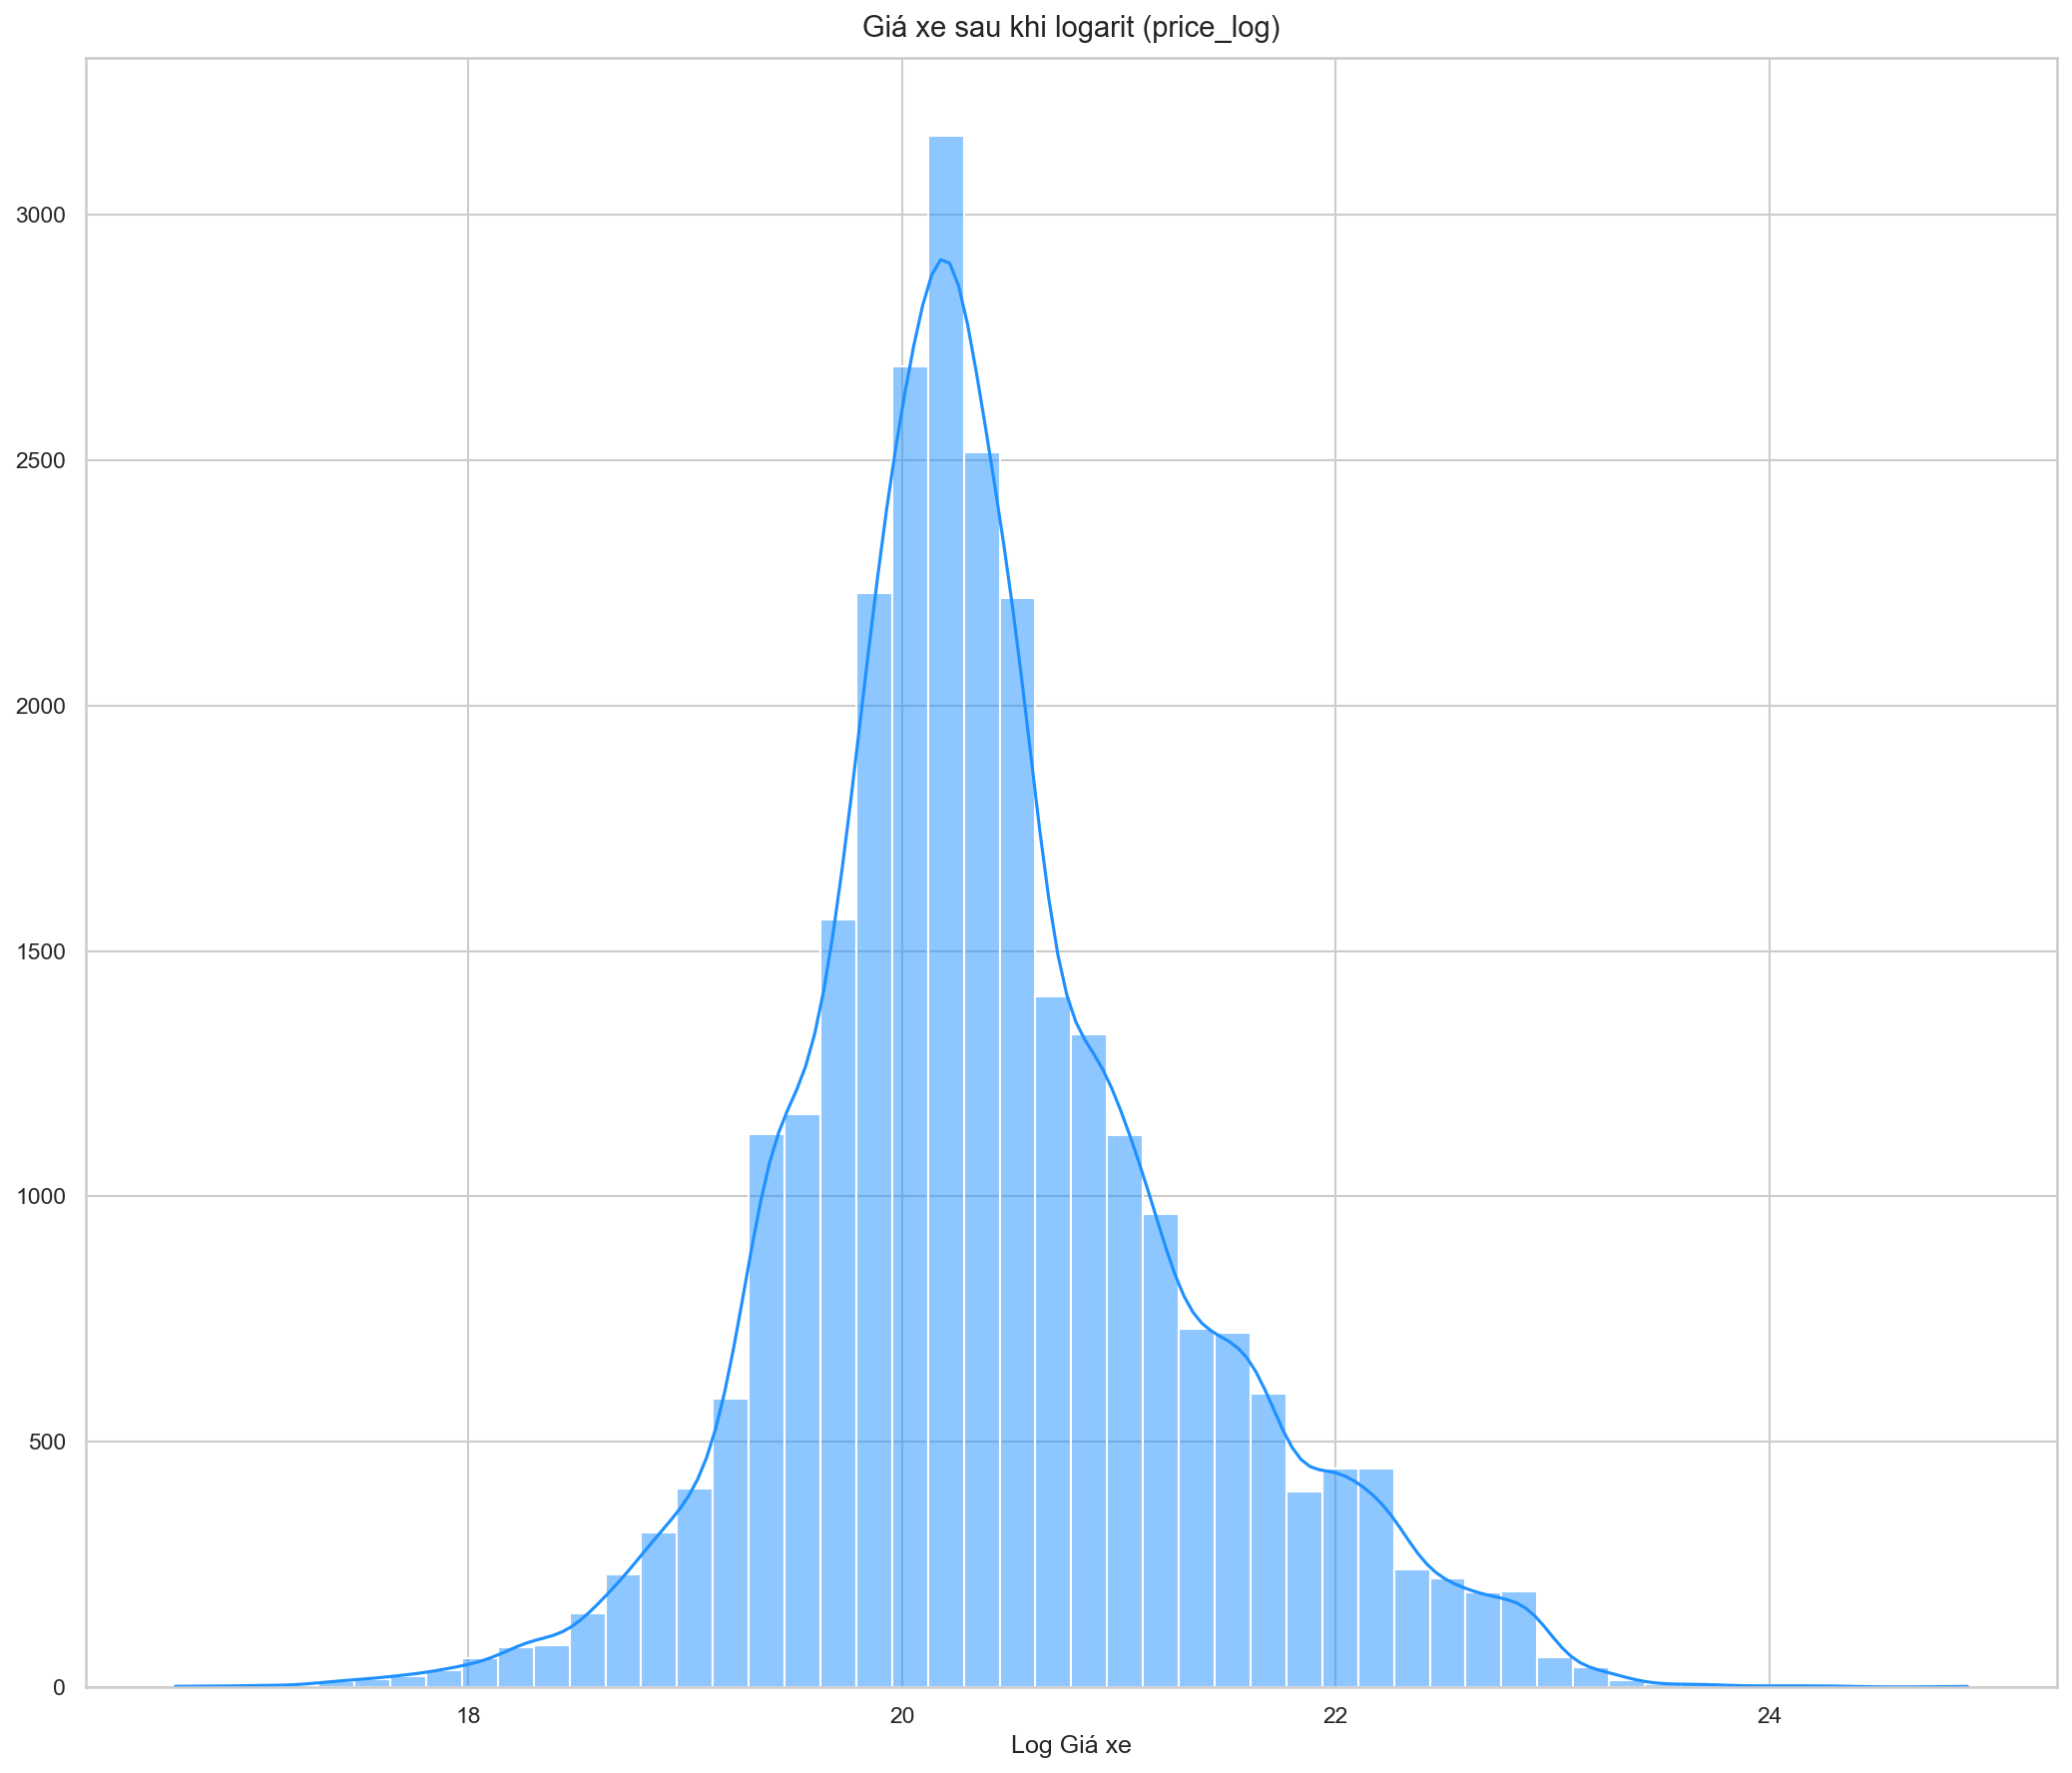

In [7]:
fig, ax = plt.subplots(
    1, 1,
    figsize=(14, 12),
    dpi=150
)

sns.histplot(df['price_log'], kde=True, bins=50, ax=ax, color='dodgerblue')
ax.set_title('Giá xe sau khi logarit (price_log)', fontsize=14, pad=10)
ax.set_xlabel('Log Giá xe')
ax.set_ylabel('')

plt.tight_layout()
plt.subplots_adjust(hspace=0.35, wspace=0.25)

plt.savefig(
    'Distribution_price_log.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()

In [5]:
upper = df['odo'].quantile(0.99)

df['odo_win'] = df['odo'].clip(upper=upper)

# Drop odo để tránh đa cộng tuyến
df = df.drop(columns=['odo'])

# Cập nhật numerical features
numerical_features = df.select_dtypes(include='number').columns


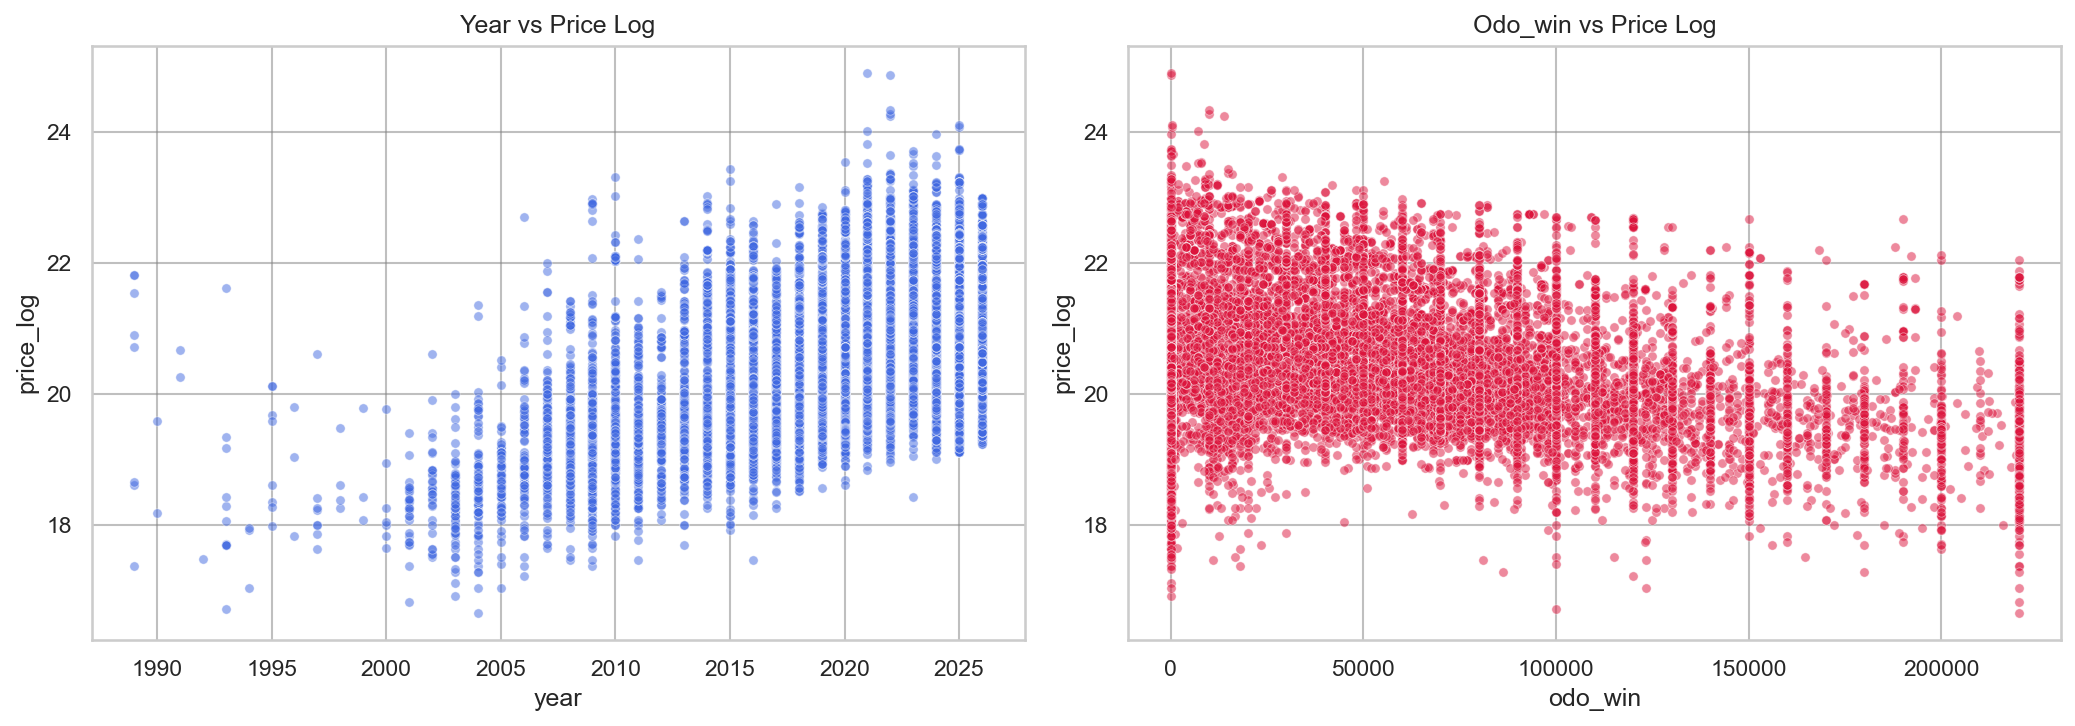

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=150, facecolor='white')
axes[0].set_facecolor('white')
axes[1].set_facecolor('white')

# --- Đồ thị 1: Year vs Price Log ---
sns.scatterplot(
    data=df,
    x='year',
    y='price_log',
    ax=axes[0],
    color='royalblue',
    alpha=0.5,
    s=20
)
axes[0].set_title('Year vs Price Log')
axes[0].grid(alpha=0.5, color='gray')

# --- Đồ thị 2: Odo vs Price Log ---
sns.scatterplot(
    data=df,
    x='odo_win',
    y='price_log',
    ax=axes[1],
    color='crimson',
    alpha=0.5,
    s=20
)
axes[1].set_title('Odo_win vs Price Log')
axes[1].grid(alpha=0.5, color='gray')

plt.tight_layout()
plt.savefig(
    'Scatterplots.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()

Nhận xét:
- Year càng cao (xe càng mới) thì giá xe có xu hướng tăng.
- Odo càng cao (xe chạy nhiều) thì giá xe có xu hướng giảm.

### Hệ số tương quan và phân tích Pearson của giá xe so với các yếu tố tác động ###

Hệ số tương quan của các biến với Price:
price        1.000000
price_log    0.770982
volume       0.298493
year         0.174624
lat          0.039847
lon          0.030727
doors        0.022257
seats       -0.027273
province    -0.079184
odo_win     -0.154860
Name: price, dtype: float64

Hệ số tương quan của các biến với Price_log:
price_log    1.000000
price        0.770982
year         0.429059
volume       0.240253
doors        0.110965
seats        0.067140
lon          0.060255
lat          0.053443
province    -0.118683
odo_win     -0.253580
Name: price_log, dtype: float64


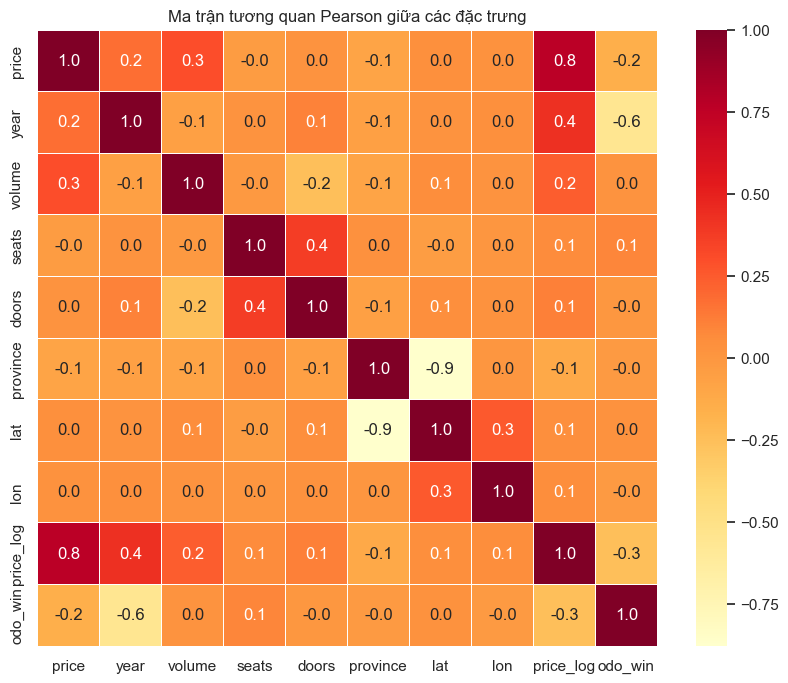

In [10]:
numerical_df = df[numerical_features]

# Pearson Correlation
correlation_matrix = numerical_df.corr(method='pearson')

print("Hệ số tương quan của các biến với Price:")
print(correlation_matrix['price'].sort_values(ascending=False))

print("\nHệ số tương quan của các biến với Price_log:")
print(correlation_matrix['price_log'].sort_values(ascending=False))

# Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='YlOrRd',
    fmt='.1f',
    linewidths=0.5
)

plt.title('Ma trận tương quan Pearson giữa các đặc trưng')
plt.savefig(
    'Pearson.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()

* **Đặc trưng cốt lõi:**
    * **`year` (0.46):** Là yếu tố có tương quan tuyến tính mạnh nhất với giá xe. Xe càng đời mới, giá trị giữ lại càng cao.
    * **`volume` (0.38):** Dung tích động cơ đại diện tốt cho phân khúc xe (hạng A, B, C hoặc xe sang/thể thao). Dung tích lớn thường đi kèm với mức giá cao hơn.
    * **`odo_win` (-0.22):** Phản ánh hao mòn vật lý thực tế. Mối quan hệ tương quan nghịch cho thấy số km lăn bánh càng lớn, giá trị xe càng giảm.

* **Nhiễu:**
    Nhóm biến bao gồm **`doors` (0.08)**, **`lat` (0.07)**, **`lon` (0.06)**, và **`seats` (0.04)** có hệ số tương quan cực kỳ thấp, gần tiệm cận 0. Những đặc trưng này hầu như không hữu ích cho việc dự đoán giá xe, ngược lại có thể gây ra nhiễu (noise) và làm phức tạp hóa mô hình.

* **Đa cộng tuyến:**
    Biến `province` có tương quan nghịch với `lat` và `lon`. Để tránh rườm rà về thông tin không gian, các tọa độ địa lý sẽ bị loại bỏ. Yếu tố khu vực có thể sẽ được tiếp cận lại qua biến `province` dưới dạng phân loại (Categorical) ở các bước mã hóa sau.

In [6]:
# Drop các cột có correlation thấp
df.drop(columns=['seats'], inplace=True)

# Cập nhật numerical features
numerical_features = df.select_dtypes(include='number').columns

### Thêm feature Age:

* **Mục đích:** Đặc trưng `year` (Năm sản xuất) mang tính chất định danh thời điểm hơn là một khoảng cách đo lường. Việc tạo ra đặc trưng mới `age` (Tuổi của xe) giúp trực tiếp lượng hóa thời gian lăn bánh và mức độ hao mòn vật lý của xe.
* **Tác động đến Mô hình:** Biến số `age` mang ý nghĩa độ lớn (magnitude) rõ ràng (xe 10 tuổi hao mòn gấp đôi xe 5 tuổi). Điều này giúp các thuật toán (đặc biệt là Regression) tối ưu hóa trọng số (weights) một cách tuyến tính và dễ dàng nắm bắt đường cong khấu hao (Depreciation Curve) hơn rất nhiều so với việc giữ nguyên số năm.
* **Hành động tiếp theo:** Sau khi tạo thành công cột `age`, cột `year` gốc có thể được loại bỏ (drop) khỏi tập dữ liệu huấn luyện để tránh hiện tượng Đa cộng tuyến (Multicollinearity) do hai biến này cung cấp lượng thông tin hoàn toàn trùng lặp.

In [7]:
import datetime

current_year = datetime.datetime.now().year

df['age'] = current_year - df['year']

print("Đã tạo thành công cột 'age'")
print(df[['year', 'age']].head())

df = df.drop(['year'], axis=1)

# Cập nhật numerical features
numerical_features = df.select_dtypes(include='number').columns

Đã tạo thành công cột 'age'
   year  age
0  2026    0
1  2026    0
2  2026    0
3  2022    4
4  2015   11


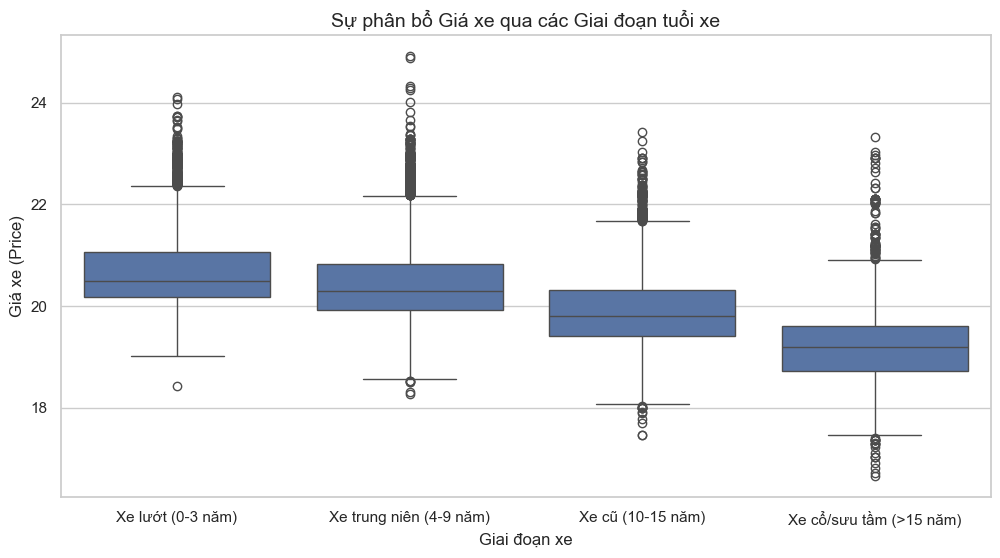

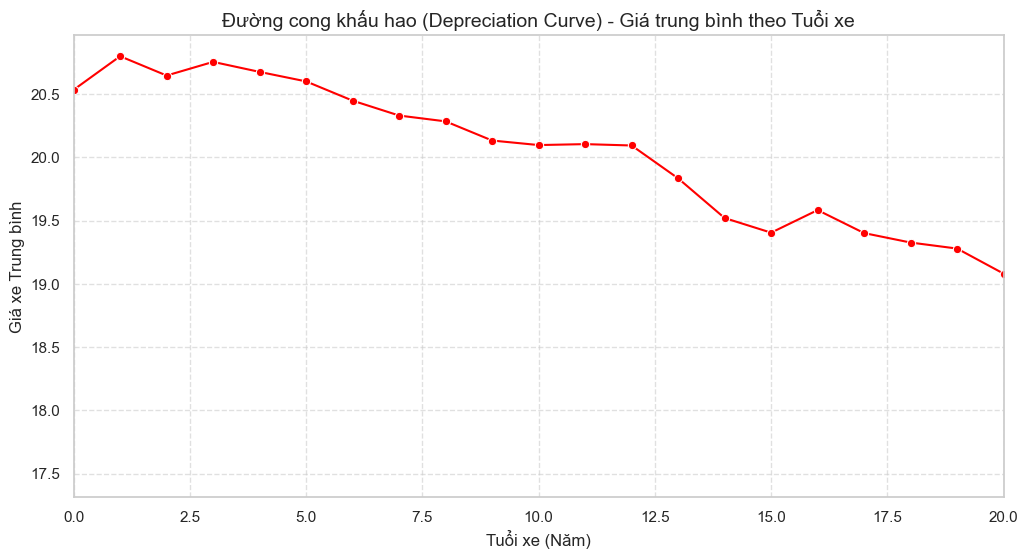

In [13]:
# Hàm phân loại giai đoạn xe
def categorize_age(age):
    if age <= 3:
        return 'Xe lướt (0-3 năm)'
    elif age <= 9:
        return 'Xe trung niên (4-9 năm)'
    elif age <= 15:
        return 'Xe cũ (10-15 năm)'
    else:
        return 'Xe cổ/sưu tầm (>15 năm)'

# Tạo 'car_phase' để phân nhóm
df['car_phase'] = df['age'].apply(categorize_age)

# Bước 2.3: Trực quan hóa phân phối giá xe theo từng giai đoạn (Boxplot)
plt.figure(figsize=(12, 6))
sns.boxplot(x='car_phase', y='price_log', data=df,
            order=['Xe lướt (0-3 năm)', 'Xe trung niên (4-9 năm)',
                   'Xe cũ (10-15 năm)', 'Xe cổ/sưu tầm (>15 năm)'])

plt.title('Sự phân bổ Giá xe qua các Giai đoạn tuổi xe', fontsize=14)
plt.xlabel('Giai đoạn xe')
plt.ylabel('Giá xe (Price)')
# Loại bỏ các điểm outliers nếu biểu đồ bị nhiễu quá nhiều bằng tham số showfliers=False trong sns.boxplot
plt.savefig(
    'Age_to_price_1.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()

# Bước 2.4: Trực quan hóa tốc độ rớt giá trung bình qua từng năm (Line chart)
plt.figure(figsize=(12, 6))
# Tính giá trung bình theo từng năm tuổi
average_price_by_age = df.groupby('age')['price_log'].mean().reset_index()

sns.lineplot(x='age', y='price_log', data=average_price_by_age, marker='o', color='red')
plt.title('Đường cong khấu hao (Depreciation Curve) - Giá trung bình theo Tuổi xe', fontsize=14)
plt.xlabel('Tuổi xe (Năm)')
plt.ylabel('Giá xe Trung bình')
plt.grid(True, linestyle='--', alpha=0.6)
plt.xlim(0, 20) # Giới hạn quan sát tới 20 năm để tránh nhiễu từ xe cổ
df = df.drop(columns=['car_phase'])
plt.savefig(
    'Age_to_price_2.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

* **Khấu hao theo Tỷ lệ phần trăm (Log-Linear Depreciation):** Trên Line Chart, từ năm thứ 4 đến năm thứ 15, đường giá trị trung bình (`price_log`) giảm theo một đường dốc xuống gần như tuyến tính. Do đây là trục logarit, một đường thẳng đi xuống đồng nghĩa với việc: Xe cũ rớt giá theo một tỷ lệ phần trăm nhất định mỗi năm chứ không rớt theo một số tiền cố định.

* **3 giai đoạn chính của vòng đời ô tô cũ:**
    * *Giai đoạn Giữ giá / Biến động cục bộ (0-4 năm):* Đường giá khá đi ngang và có phần gập ghềnh. Nguyên nhân do số lượng xe bán lướt thường ít, hoặc bị chi phối mạnh bởi các dòng xe đang "hot" có độ giữ giá cao. Ở giai đoạn này, odo (số km) có thể đóng vai trò mạnh hơn cả số năm tuổi.
    * *Giai đoạn Rớt giá tiêu chuẩn (4-15 năm):* Đây là "vùng vàng" (golden zone) của thị trường. Đường khấu hao cực kỳ rõ ràng và ổn định.
    * *Giai đoạn "Chạm đáy" (>15 năm):* Giá trị xe đi ngang và biến động thất thường. Tuổi xe không còn là yếu tố quyết định; lúc này, giá trị phụ thuộc vào việc xe còn hoạt động được không hoặc có giá trị sưu tầm không.

* **Outliers từ Boxplot:**
    Biểu đồ Boxplot cho thấy ở **tất cả các giai đoạn** đều tồn tại lượng lớn các outliers ở cả phía trên và phía dưới hộp.
    * *Outliers phía trên:* Các dòng xe siêu sang, xe thể thao (Rolls-Royce, Porsche...) giữ giá vượt trội so với mặt bằng chung.
    * *Outliers phía dưới:* Nguy cơ là các xe tai nạn, xe ngập nước, hoặc lỗi nhập liệu.

### Phân bổ giá xe theo hãng

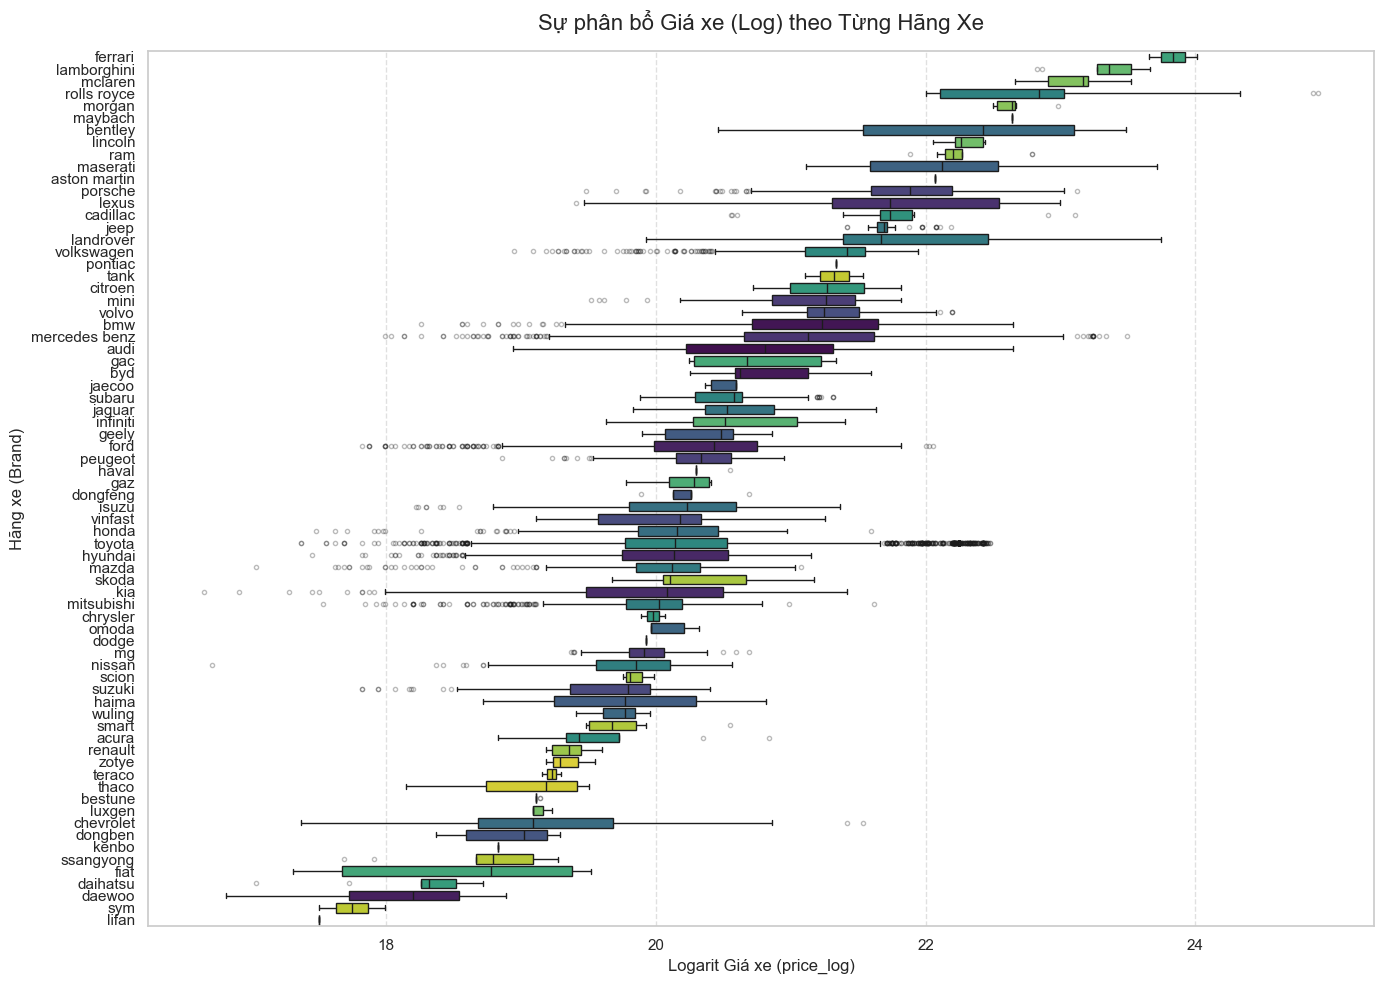

In [14]:
plt.figure(figsize=(14, 10))

# Tính giá trị trung vị (median) của price_log cho từng hãng và sắp xếp giảm dần
brand_order = df.groupby('brand')['price_log'].median().sort_values(ascending=False).index

# Vẽ Boxplot (Đã fix lỗi palette deprecation)
sns.boxplot(x='price_log',
            y='brand',
            data=df,
            order=brand_order,
            palette='viridis',
            hue='brand',       # Thêm hue bằng chính biến y
            legend=False,      # Tắt legend để tránh bị trùng lặp
            flierprops={'marker': 'o', 'markersize': 3, 'alpha': 0.3})

plt.title('Sự phân bổ Giá xe (Log) theo Từng Hãng Xe', fontsize=16, pad=15)
plt.xlabel('Logarit Giá xe (price_log)', fontsize=12)
plt.ylabel('Hãng xe (Brand)', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(
    'Brand.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()

**1. Sự phân tầng rõ rệt:**
Thị trường xe cũ bị chia cắt thành các phân khúc rất sắc nét:
* **Nhóm Luxury (Dẫn đầu):** LandRover, Porsche, Lexus, Audi, Volvo, BMW, Mercedes-Benz. Nhóm này có mức giá trung vị vượt trội hoàn toàn (dao động quanh mức 22.0 - 24.0 trên thang logarit).
* **Nhóm Mid-range (Tầm trung):** Jeep, Mini, VinFast, Subaru, Peugeot, Ford, Honda. Nhóm này tạo thành một dải chuyển tiếp mượt mà ở giữa biểu đồ. Đáng chú ý, **VinFast** đang định vị mình vững chắc ở phân khúc này, ngang hàng với các dòng xe Âu/Mỹ và nhỉnh hơn một chút so với xe Nhật bình dân.
* **Nhóm Budget (Bình dân/Giá rẻ):** Hyundai, Toyota, Mazda, Mitsubishi, Suzuki, Nissan, Kia, Chevrolet, Daewoo. Nhóm này tập trung ở đáy biểu đồ, là nơi diễn ra các giao dịch sôi động nhất của thị trường đại chúng.

**2. Variance & Outliers:**
* **Sự dãn cách của Box (Độ biến động giá):** Hãng **Porsche** có chiều dài hình hộp (IQR) rộng nhất trong nhóm đầu. Điều này phản ánh đặc thù của xe Porsche: giá xe cũ dao động cực kỳ khủng khiếp phụ thuộc vào các gói trang bị tùy chọn (options) mà chủ cũ đã lắp, thay vì chỉ dựa vào xác xe nguyên bản.
* **Đám mây Ngoại lai (Outliers Density):** Các hãng như **Mercedes-Benz, Toyota, và Hyundai** sở hữu lượng điểm outliers (các chấm tròn) dày đặc một cách bất thường, kéo dài lên tít phía trên.
    * *Giải thích:* Đây là các hãng có **dải sản phẩm quá rộng**. Ví dụ: Toyota bán cả Wigo (giá vài trăm triệu) cho đến Land Cruiser / Alphard (giá nhiều tỷ đồng). Mercedes có cả C180 (dễ tiếp cận) lẫn G63 AMG / Maybach (siêu đắt).

### Độ rớt giá của các hãng xe

In [8]:
# Top 20 hãng phổ biến nhất
top_brands = df['brand'].value_counts().nlargest(5).index

# Tạo DataFrame chứa dữ liệu của Top 20
df_top_brands = df[df['brand'].isin(top_brands)]
print(df_top_brands['brand'].value_counts())

brand
toyota           4220
ford             2967
mercedes benz    2933
hyundai          2812
vinfast          2321
Name: count, dtype: int64


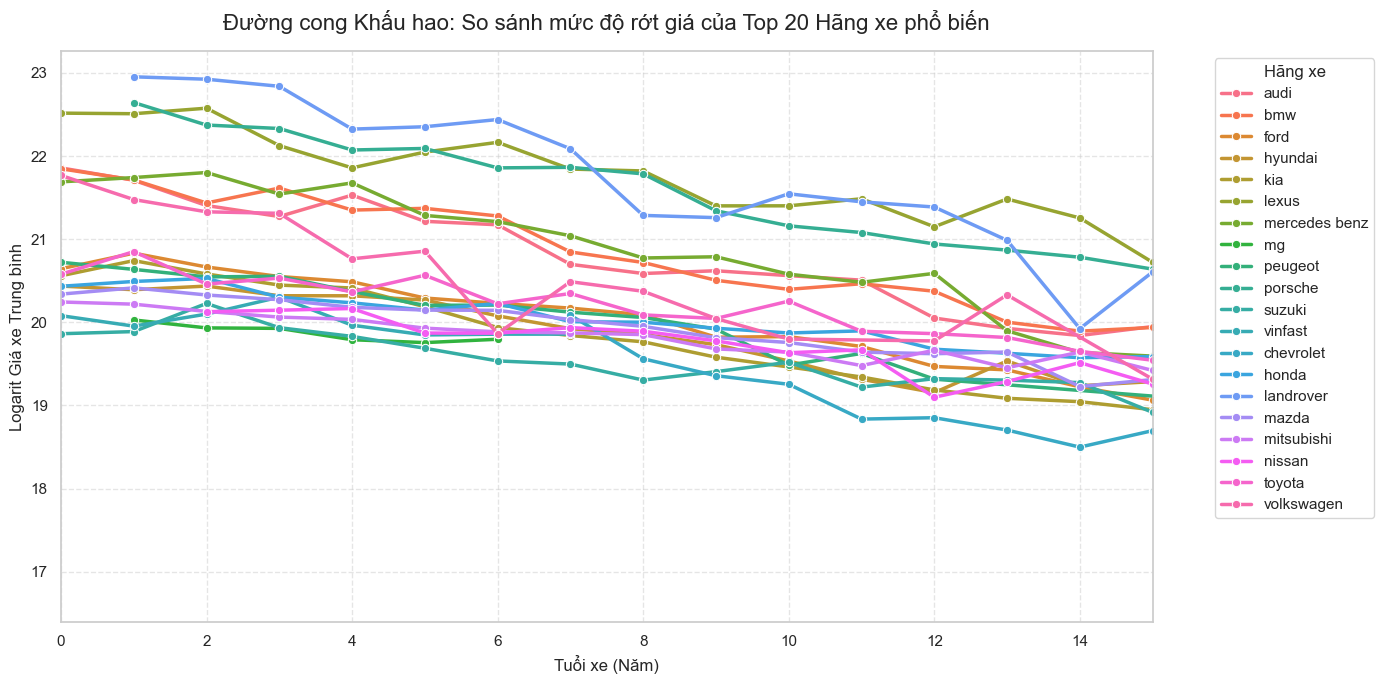

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Top 20 hãng phổ biến nhất
top_brands = df['brand'].value_counts().nlargest(20).index

# Tạo DataFrame chứa dữ liệu của Top 20
df_top_brands = df[df['brand'].isin(top_brands)]

plt.figure(figsize=(14, 7))

# Line chart so sánh khấu hao
sns.lineplot(x='age',
             y='price_log',
             hue='brand',
             data=df_top_brands,
             marker='o',
             errorbar=None, # THAY THẾ ci=None BẰNG errorbar=None
             linewidth=2.5)

# Đã sửa lại tiêu đề cho khớp với dữ liệu thực tế (Top 6)
plt.title('Đường cong Khấu hao: So sánh mức độ rớt giá của Top 20 Hãng xe phổ biến', fontsize=16, pad=15)
plt.xlabel('Tuổi xe (Năm)', fontsize=12)
plt.ylabel('Logarit Giá xe Trung bình', fontsize=12)

# Chỉnh sửa lại phần ghi chú (Legend)
plt.legend(title='Hãng xe', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.xlim(0, 15) # Tập trung phân tích 15 năm đầu tiên

plt.tight_layout()

plt.savefig('Price_drop.png', dpi=300, bbox_inches='tight')

plt.show()

**1. Nhóm Xe Sang (Luxury Brands) - Rớt giá không phanh:**
* **Quan sát:** Tập hợp các đường nằm trên cùng của đồ thị (bao gồm Porsche, LandRover, Mercedes-Benz, BMW, Audi). Các đường này có điểm xuất phát rất cao nhưng độ dốc cắm xuống cực kỳ mạnh, đặc biệt là trong dải từ 0 đến 7 năm tuổi.
* **Ý nghĩa:** Vì trục Y là logarit, độ dốc lớn đồng nghĩa với tỷ lệ phần trăm rớt giá hàng năm rất cao. Một chiếc xe Đức có thể mất tới 10-15% giá trị mỗi năm trong những năm đầu. Mua xe sang lướt (3-5 năm) sẽ né được cú "rơi tự do" này, nhưng người mua xe mới sẽ phải chịu khoản khấu hao khổng lồ.

**2. Nhóm Xe Phổ Thông (Mainstream Brands) - Khấu hao trung bình:**
* **Quan sát:** Đây là "búi dây" kẹp chặt lấy nhau ở nửa dưới của biểu đồ (dao động trong khoảng log từ 20 đến 21.5), đại diện cho Toyota, Honda, Hyundai, Kia, Mazda, v.v. Các đường này có độ dốc thoải (phẳng hơn rất nhiều) so với nhóm xe sang.
* **Ý nghĩa:** Xe Nhật, Hàn bình dân có tỷ lệ mất giá hàng năm thấp và cực kỳ ổn định.

**3. Hiện tượng đứt gãy dữ liệu (VinFast & Xe mới nổi):**
* **Quan sát:** Có những đường ngắn bị cắt đứt đột ngột ở mốc 5-6 năm (ví dụ: VinFast).
* **Ý nghĩa:** Đây không phải lỗi dữ liệu, mà phản ánh lịch sử của hãng xe. VinFast mới ra mắt thị trường vài năm trở lại đây nên hoàn toàn không tồn tại những chiếc xe 10 hay 15 năm tuổi.

**KẾT LUẬN:**
Sự khác biệt về độ dốc giữa các đường khẳng định Interaction Effect cực kỳ mạnh mẽ giữa `brand` và `age`: Cùng tăng thêm 1 tuổi, nhưng xe Mercedes sẽ bị trừ nhiều tiền hơn xe Toyota.

### Phân khúc Hãng xe (Feature Engineering)

In [9]:
# Tính mức giá trung vị của từng hãng để làm cơ sở xếp hạng
brand_median_price = df.groupby('brand')['price_log'].median().reset_index()
brand_median_price.columns = ['brand', 'median_price_log']

# Tự động chia các hãng thành 3 nhóm có số lượng tương đương nhau (q=3)
brand_median_price['brand_tier'] = pd.qcut(brand_median_price['median_price_log'],
                                           q=3,
                                           labels=['Eco',
                                                   'Mid-range',
                                                   'Luxury'])


df = df.merge(brand_median_price[['brand', 'brand_tier']], on='brand', how='left')

# In kết quả kiểm tra xem việc phân nhóm có hợp lý với thực tế không
print("="*50)
print("DANH SÁCH PHÂN CỤM HÃNG XE (BRAND TIERS):")
print("="*50)
# Xem thử danh sách một số hãng xe ở từng nhóm
for tier in ['Luxury', 'Mid-range', 'Eco']:
    brands_in_tier = brand_median_price[brand_median_price['brand_tier'] == tier]['brand'].tolist()
    print(f"\n[{tier}]:")
    print(", ".join(brands_in_tier))

DANH SÁCH PHÂN CỤM HÃNG XE (BRAND TIERS):

[Luxury]:
aston martin, bentley, bmw, cadillac, citroen, ferrari, jeep, lamborghini, landrover, lexus, lincoln, maserati, maybach, mclaren, mercedes benz, mini, morgan, pontiac, porsche, ram, rolls royce, tank, volkswagen, volvo

[Mid-range]:
audi, byd, chrysler, dongfeng, ford, gac, gaz, geely, haval, honda, hyundai, infiniti, isuzu, jaecoo, jaguar, kia, mazda, mitsubishi, omoda, peugeot, skoda, subaru, toyota, vinfast

[Eco]:
acura, bestune, chevrolet, daewoo, daihatsu, dodge, dongben, fiat, haima, kenbo, lifan, luxgen, mg, nissan, renault, scion, smart, ssangyong, suzuki, sym, teraco, thaco, wuling, zotye


### Mật độ phân bố

(10.0, 25.0)

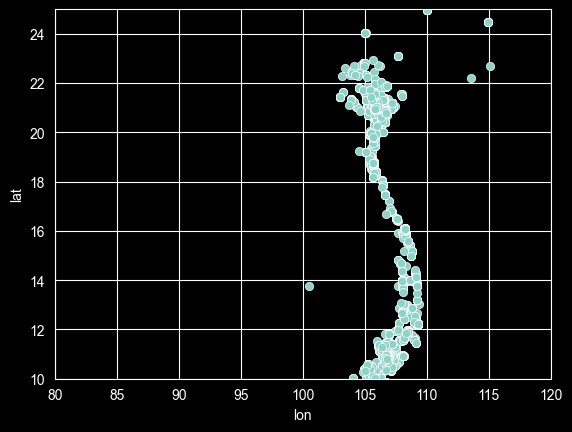

In [18]:
sns.scatterplot(x='lon', y='lat', data=df)
plt.xlim(80, 120)
plt.ylim(10, 25)

In [18]:
df_coords = pd.read_csv('../../../data/provinces_coordinates.json', index_col=0)

province_mapping = df_coords['province'].to_dict()

df['province_name'] = df['province'].map(province_mapping)
df['province_name'] = df['province_name'].str.title()

### Top 10 tỉnh nhiều xe nhất

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_23692\3446064768.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_provinces.values, y=top_provinces.index, orient='h', palette='viridis')


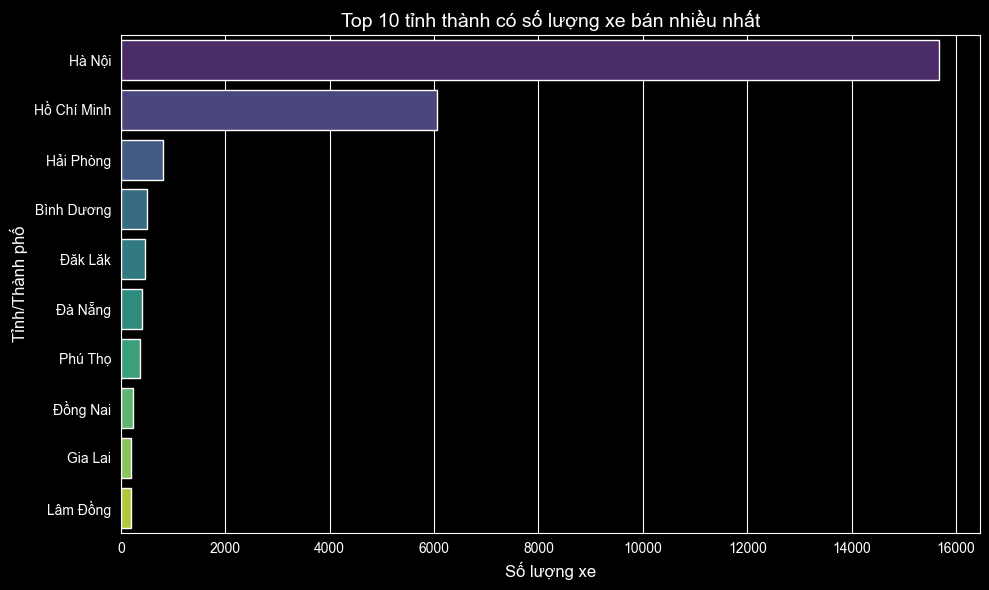

In [22]:
plt.figure(figsize=(10, 6))

# Chạy dòng này trước khi lấy top_provinces
df['province_name'] = df['province_name'].replace('Tp Hcm', 'Hồ Chí Minh')
# Đếm số lượng theo cột tên tỉnh mới
top_provinces = df['province_name'].value_counts().head(10)

sns.barplot(x=top_provinces.values, y=top_provinces.index, orient='h', palette='viridis')

plt.title('Top 10 tỉnh thành có số lượng xe bán nhiều nhất', fontsize=14)
plt.xlabel('Số lượng xe', fontsize=12)
plt.ylabel('Tỉnh/Thành phố', fontsize=12)
plt.tight_layout()
plt.show()

# Lưu danh sách tên tỉnh để dùng tiếp
top_prov_list = top_provinces.index.tolist()

### Giá xe trung bình theo top tỉnh thành

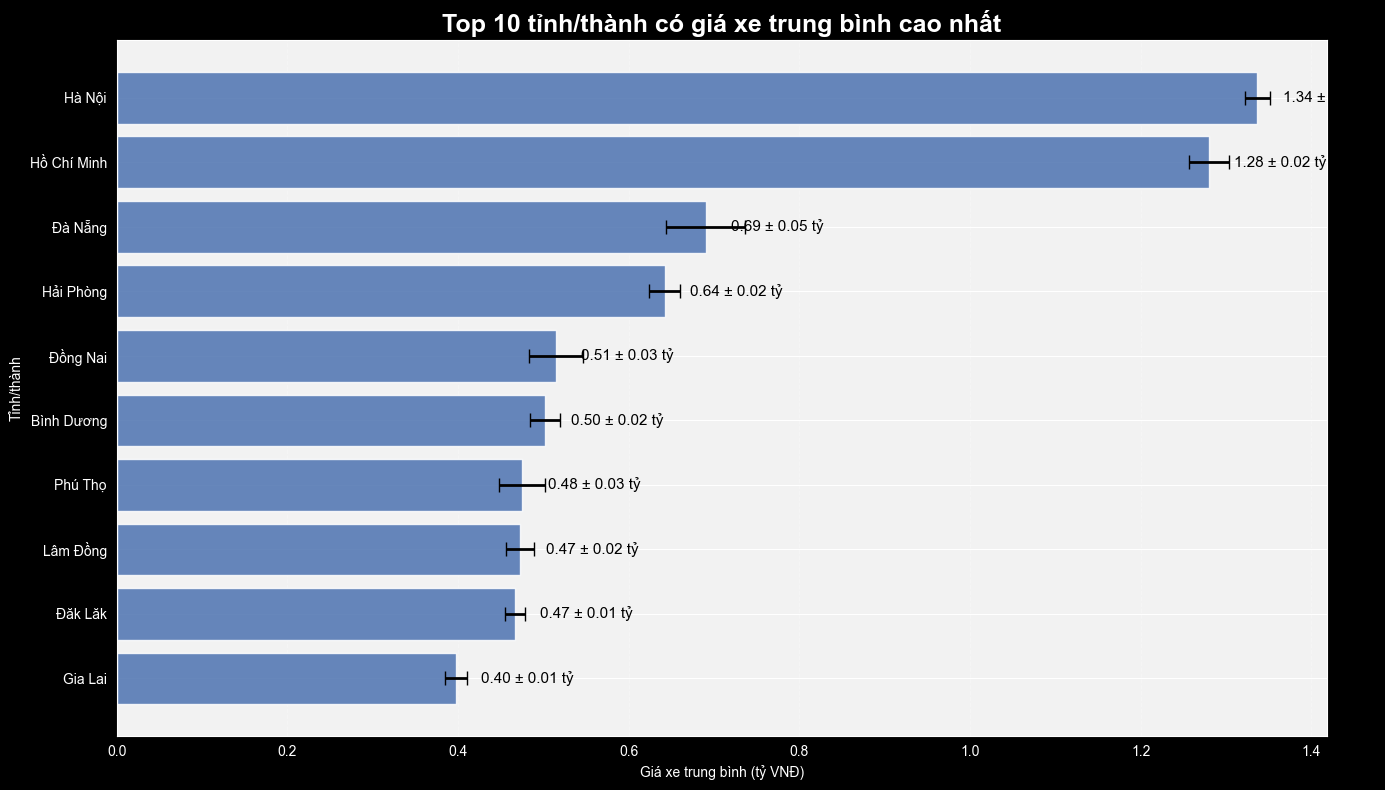

In [28]:
plt.figure(figsize=(14, 8))

# Lọc top tỉnh
df_top = df[df['province_name'].isin(top_prov_list)]

# Tính mean + SEM
stats = (
    df_top
    .groupby('province_name')['price']
    .agg(
        mean='mean',
        sem='sem'      # standard error
    )
)

# Giữ thứ tự
stats = stats.reindex(top_prov_list)

# Chuyển sang tỷ
stats['mean_b'] = stats['mean'] / 1e9
stats['sem_b'] = stats['sem'] / 1e9

# Sắp xếp giảm dần (giống hình)
stats = stats.sort_values('mean_b', ascending=False)

# Vẽ
plt.barh(
    stats.index,
    stats['mean_b'],
    xerr=stats['sem_b'],   # ← dùng sem_b
    color='#4C72B0',
    alpha=0.85,
    error_kw={
        'capsize': 5,
        'elinewidth': 2,
        'ecolor': 'black'
    }
)

plt.gca().invert_yaxis()

# Label
for i, row in enumerate(stats.itertuples()):
    plt.text(
        row.mean_b + 0.03,
        i,
        f'{row.mean_b:.2f} ± {row.sem_b:.2f} tỷ',
        va='center',
        fontsize=11,
        color='black'
    )

plt.title(
    'Top 10 tỉnh/thành có giá xe trung bình cao nhất',
    fontsize=18,
    weight='bold'
)

plt.xlabel('Giá xe trung bình (tỷ VNĐ)')
plt.ylabel('Tỉnh/thành')

plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.gca().set_facecolor('#f2f2f2')

plt.tight_layout()
plt.show()

### Heatmap — Phân bố thương hiệu xe theo tỉnh/thành

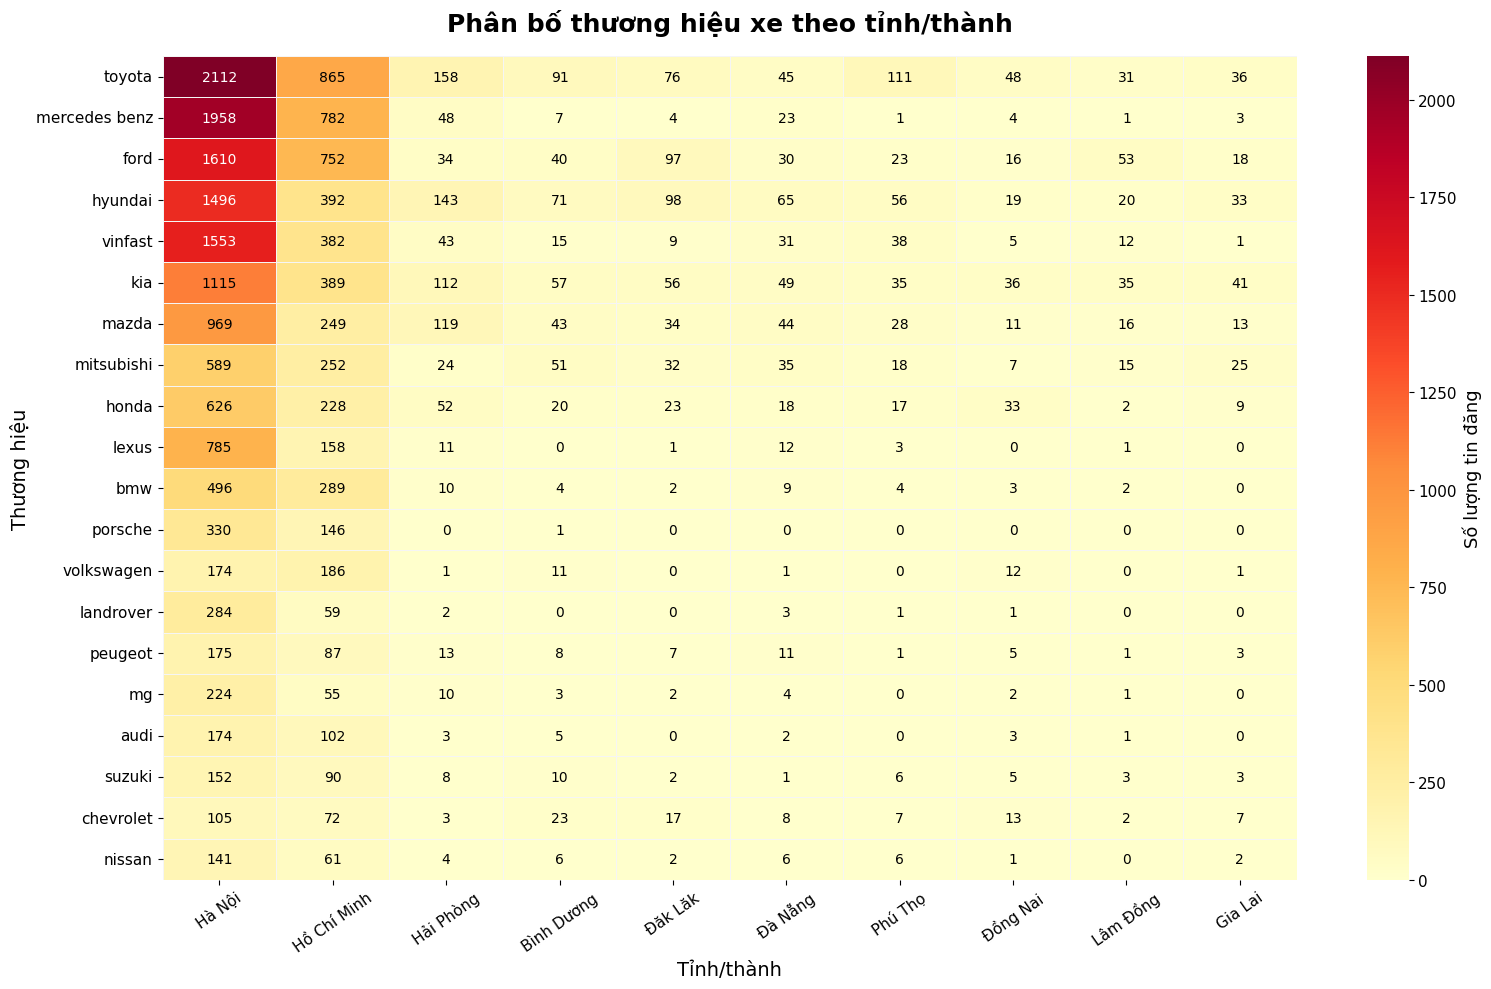

In [45]:
top_provinces = (
    df['province_name']
    .value_counts()
    .head(10)
    .index
)

top_brands = (
    df['brand']
    .value_counts()
    .head(20)
    .index
)

# Pivot đếm số lượng
heat = (
    df[
        (df['province_name'].isin(top_provinces)) &
        (df['brand'].isin(top_brands))
    ]
    .pivot_table(
        index='brand',
        columns='province_name',
        values='price',
        aggfunc='count',
        fill_value=0
    )
)

# Sắp xếp hàng theo tổng giảm dần
heat = heat.loc[
    heat.sum(axis=1)
    .sort_values(ascending=False)
    .index
]

# Sắp xếp cột theo tổng giảm dần
heat = heat[
    heat.sum(axis=0)
    .sort_values(ascending=False)
    .index
]

plt.style.use('default')

top_provinces = (
    df['province_name']
    .value_counts()
    .head(10)
    .index
)

top_brands = (
    df['brand']
    .value_counts()
    .head(20)
    .index
)

# Pivot
heat = (
    df[
        (df['province_name'].isin(top_provinces)) &
        (df['brand'].isin(top_brands))
    ]
    .pivot_table(
        index='brand',
        columns='province_name',
        values='price',
        aggfunc='count',
        fill_value=0
    )
)

# Sort
heat = heat.loc[
    heat.sum(axis=1)
    .sort_values(ascending=False)
    .index
]

heat = heat[
    heat.sum(axis=0)
    .sort_values(ascending=False)
    .index
]

# Figure
fig, ax = plt.subplots(
    figsize=(16,10),
    facecolor='white'
)

# Heatmap
hm = sns.heatmap(
    heat,

    cmap='YlOrRd',     # ← giống ảnh hơn

    annot=True,
    fmt='g',

    linewidths=0.5,
    linecolor='#F5F5F5',

    cbar_kws={
        'label': 'Số lượng tin đăng',
        'shrink': 1
    },

    ax=ax
)

# Nền trắng
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

# Chữ annotation:
threshold = heat.values.max() * 0.55

for txt in hm.texts:
    try:
        val = float(txt.get_text())
        txt.set_color(
            'white'
            if val > threshold
            else 'black'
        )
    except:
        pass

# Title
ax.set_title(
    'Phân bố thương hiệu xe theo tỉnh/thành',
    fontsize=18,
    fontweight='bold',
    pad=18,
    color='black'
)

# Label
ax.set_xlabel(
    'Tỉnh/thành',
    fontsize=14,
    color='black'
)

ax.set_ylabel(
    'Thương hiệu',
    fontsize=14,
    color='black'
)

# Tick
ax.tick_params(
    colors='black',
    labelsize=11
)

plt.xticks(rotation=35)
plt.yticks(rotation=0)

# Colorbar
cbar = hm.collections[0].colorbar
cbar.ax.tick_params(
    labelsize=11,
    colors='black'
)

cbar.set_label(
    'Số lượng tin đăng',
    fontsize=13
)

plt.tight_layout()

plt.savefig(
    'brand_distribution_by_province.png',
    dpi=300,
    bbox_inches='tight',
    facecolor='white'
)

plt.show()

### Line chart — Giá xe trung bình từng thương hiệu theo tỉnh/thành

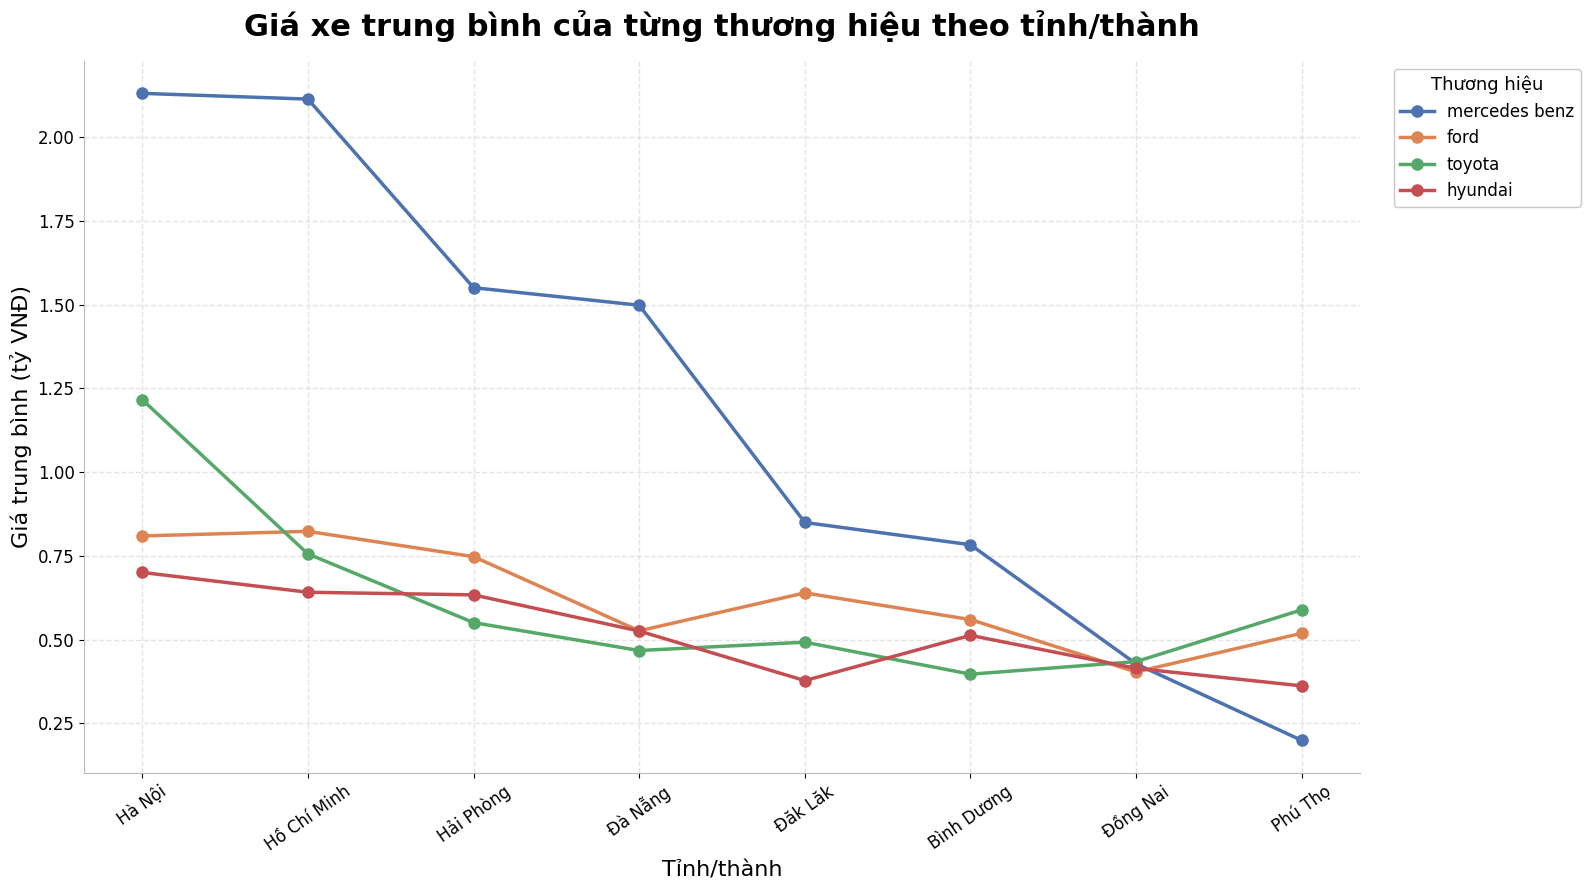

In [44]:
import matplotlib.pyplot as plt

# Chọn top brand
top_brand_price = (
    df['brand']
    .value_counts()
    .head(4)
    .index
)

# Chọn top tỉnh
top_provinces_price = (
    df['province_name']
    .value_counts()
    .head(8)
    .index
)

temp = df[
    (df['brand'].isin(top_brand_price)) &
    (df['province_name'].isin(top_provinces_price))
]

# Tính mean
avg_price = (
    temp
    .groupby(['province_name','brand'])['price']
    .mean()
    .reset_index()
)

avg_price['price_b'] = avg_price['price'] / 1e9

pivot = avg_price.pivot(
    index='province_name',
    columns='brand',
    values='price_b'
)

# Sắp xếp tỉnh theo giá TB
province_order = (
    pivot.mean(axis=1)
    .sort_values(ascending=False)
    .index
)

# Sắp xếp brand theo giá TB
brand_order = (
    pivot.mean(axis=0)
    .sort_values(ascending=False)
    .index
)

pivot = pivot.loc[
    province_order,
    brand_order
]

plt.style.use('default')

fig, ax = plt.subplots(
    figsize=(16, 9),
    facecolor='white'
)

colors = [
    '#4C72B0',   # ford
    '#DD8452',   # hyundai
    '#55A868',   # mercedes
    '#C44E52'    # toyota
]

# Line
for i, brand in enumerate(pivot.columns):

    ax.plot(
        pivot.index,
        pivot[brand],

        marker='o',
        markersize=8,

        linewidth=2.5,

        color=colors[i],

        label=brand
    )

fig.patch.set_facecolor('white')
ax.set_facecolor('white')
ax.grid(
    True,
    which='major',
    axis='both',
    linestyle='--',
    linewidth=1,
    color='#D9D9D9',
    alpha=0.7
)

ax.set_axisbelow(True)

# Spine
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.spines['left'].set_color('#BBBBBB')
ax.spines['bottom'].set_color('#BBBBBB')

# TITLE
ax.set_title(
    'Giá xe trung bình của từng thương hiệu theo tỉnh/thành',
    fontsize=22,
    fontweight='bold',
    color='black',
    pad=18
)

# LABEL
ax.set_xlabel(
    'Tỉnh/thành',
    fontsize=16,
    color='black'
)

ax.set_ylabel(
    'Giá trung bình (tỷ VNĐ)',
    fontsize=16,
    color='black'
)

ax.tick_params(
    axis='x',
    colors='black',
    labelsize=12
)

ax.tick_params(
    axis='y',
    colors='black',
    labelsize=12
)

plt.xticks(rotation=35)
legend = ax.legend(
    title='Thương hiệu',

    fontsize=12,
    title_fontsize=13,

    frameon=True,

    facecolor='white',

    edgecolor='#BBBBBB',

    loc='upper left',

    bbox_to_anchor=(1.02, 1)
)
legend.get_title().set_color('black')

for text in legend.get_texts():
    text.set_color('black')

plt.tight_layout()

plt.savefig(
    'brand_vs_province_report.png',
    dpi=300,
    bbox_inches='tight',
    facecolor='white'
)

plt.show()

### Heatmap — Giá trung bình từng mẫu xe theo tỉnh/thành

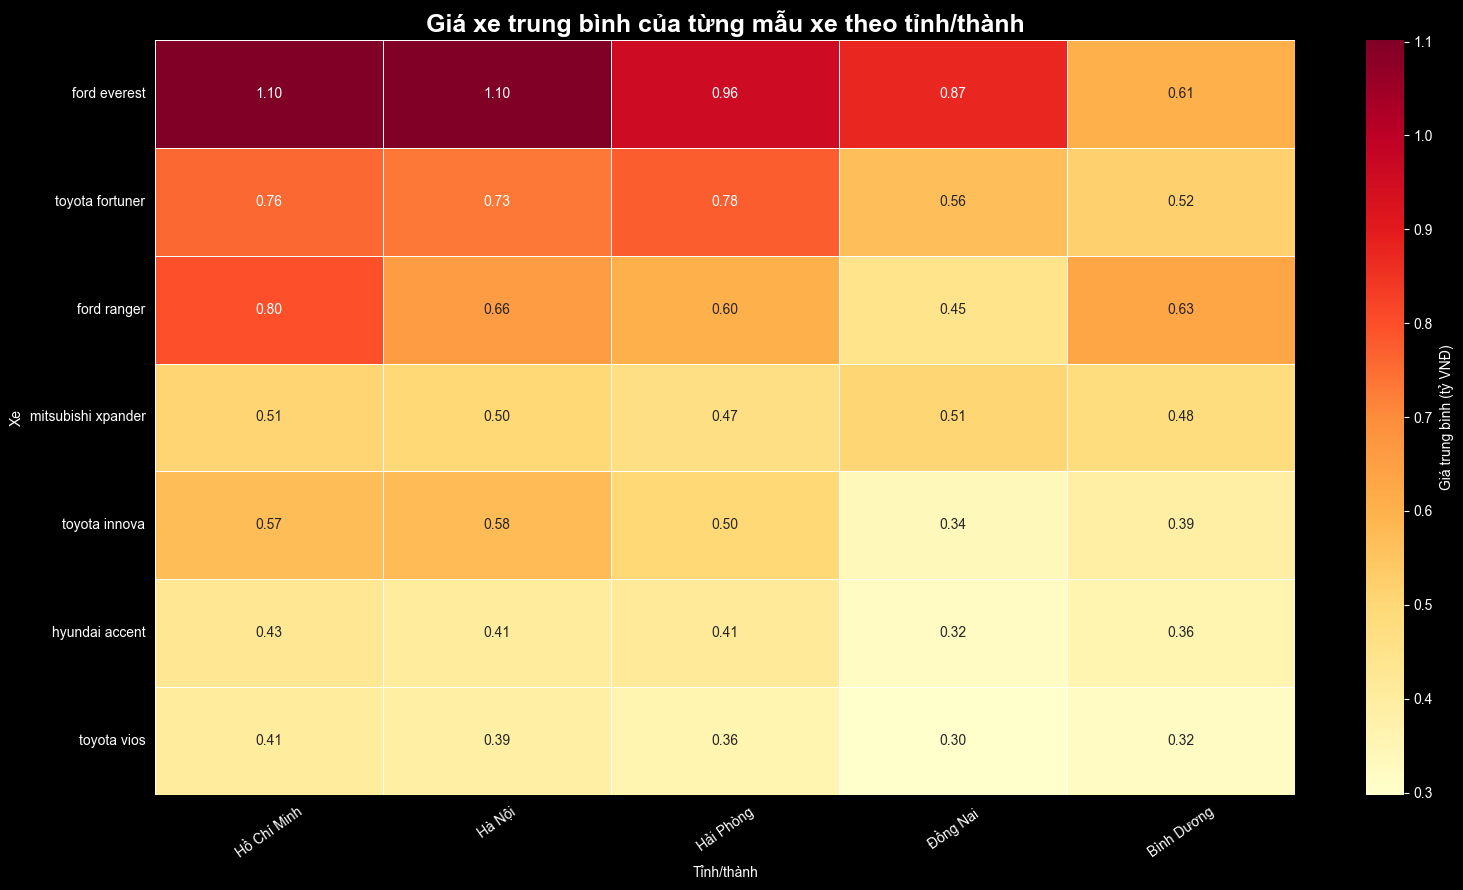

In [41]:
df['car_name'] = (
    df['brand'].str.lower().str.strip()
    + ' '
    + df['model'].str.lower().str.strip()
)

selected_cars = [
    'toyota fortuner',
    'ford ranger',
    'toyota innova',
    'hyundai accent',
    'toyota vios',
    'ford everest',
    'mitsubishi xpander'
]

selected_provinces = [
    'Hà Nội',
    'Hồ Chí Minh',
    'Hải Phòng',
    'Đồng Nai',
    'Bình Dương'
]
# Pivot giá TB
car_price = (
    df[
        (df['car_name'].isin(selected_cars)) &
        (df['province_name'].isin(selected_provinces))
    ]
    .pivot_table(
        index='car_name',
        columns='province_name',
        values='price',
        aggfunc='mean'
    )
)

# Tỷ VNĐ
car_price = car_price / 1e9

# Reindex trước để giữ đủ xe/tỉnh
car_price = car_price.reindex(
    index=selected_cars,
    columns=selected_provinces
)

# Sắp xe đắt → rẻ
row_order = (
    car_price.mean(axis=1)
    .sort_values(ascending=False)
    .index
)

# Sắp tỉnh đắt → rẻ
col_order = (
    car_price.mean(axis=0)
    .sort_values(ascending=False)
    .index
)

car_price = car_price.loc[
    row_order,
    col_order
]

# Vẽ
plt.figure(figsize=(16, 9))

sns.heatmap(
    car_price,
    annot=True,
    fmt='.2f',
    cmap='YlOrRd',
    linewidths=0.5,
    cbar_kws={
        'label': 'Giá trung bình (tỷ VNĐ)'
    }
)

plt.title(
    'Giá xe trung bình của từng mẫu xe theo tỉnh/thành',
    fontsize=18,
    weight='bold'
)

plt.xlabel('Tỉnh/thành')
plt.ylabel('Xe')

plt.xticks(rotation=35)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [17]:
df.to_csv('../../../data/bonbanh/processed/final_bonbanh.csv')